In [2]:
import numpy as np
import pandas as pd

**1. Date-Time Operations**

In [135]:
# 1. 1. string to datetime

df = pd.DataFrame({'val': [1, 2, 3], 'date': ['2026-09-04', '2026-09-03', '2026-09-02']})

print(df.dtypes)

df.date = pd.to_datetime(df.date)

print(df.dtypes)

val     int64
date      str
dtype: object
val              int64
date    datetime64[us]
dtype: object


In [4]:
# 1.2. extract part of date

df['month'] = df.date.dt.month

df['day'] = df.date.dt.day

df

,val,date,month,day
0,1,2026-09-04,9,4
1,2,2026-09-03,9,3
2,3,2026-09-02,9,2


In [139]:
# 1.3. difference between two dates

df['date2'] = pd.to_datetime('2026-08-31')
print(df)

df['date_diff'] = df['date'] - df['date2']
print(df)

print(df.dtypes)

   val       date      date2 date_diff
0    1 2026-09-04 2026-08-31    4 days
1    2 2026-09-03 2026-08-31    3 days
2    3 2026-09-02 2026-08-31    2 days
   val       date      date2 date_diff
0    1 2026-09-04 2026-08-31    4 days
1    2 2026-09-03 2026-08-31    3 days
2    3 2026-09-02 2026-08-31    2 days
val                    int64
date          datetime64[us]
date2         datetime64[us]
date_diff    timedelta64[us]
dtype: object


**2. String Operations**

In [5]:
# 2.1. to lower

df = pd.DataFrame({'name': ['BOB', 'NAUFIL'], 'id': ['abc123-011xyz', 'mno63-11556zzz']})

df['name2'] = df.name.str.lower()

df

,name,id,name2
0,BOB,abc123-011xyz,bob
1,NAUFIL,mno63-11556zzz,naufil


In [6]:
# 2.2. string split

df[['c1', 'c3']] = df['id'].str.split('-', expand = True)

df

,name,id,name2,c1,c3
0,BOB,abc123-011xyz,bob,abc123,011xyz
1,NAUFIL,mno63-11556zzz,naufil,mno63,11556zzz


In [7]:
# 2.3. String Matching : extract sub-string pattern using a Regex pattern

df['id_num'] = df.id.str.extract(r'(\d+-\d+)')
df

,name,id,name2,c1,c3,id_num
0,BOB,abc123-011xyz,bob,abc123,011xyz,123-011
1,NAUFIL,mno63-11556zzz,naufil,mno63,11556zzz,63-11556


**3. DataFrame Operations**

In [27]:
# 3.1. Filter and subset

df = pd.DataFrame({'name': ['bob', 'rob', 'tom', 'dick', 'harry'], 'score1': [40, 50, 20, 35, 45], 'score2': [50, 60, 25, 10, 35]})

print(df)

# filter records where both score1 and score2 are above 30

df_filtered =  df.iloc[(df.score1 > 30) & (df.score2 > 30),:]

print(df_filtered)

    name  score1  score2
0    bob      40      50
1    rob      50      60
2    tom      20      25
3   dick      35      10
4  harry      45      35
    name  score1  score2
0    bob      40      50
1    rob      50      60
4  harry      45      35


In [12]:
# 3.2. Apply (column mutation)

df = pd.DataFrame({'x': [1,5,3], 'y': [2,3,6], 'z': [3,4,5]})

df['max'] = df.iloc[:,:].apply(lambda x: max(x)+1, axis = 1)

df

,x,y,z,max
0,1,2,3,4
1,5,3,4,6
2,3,6,5,7


Call-out: Avoid using .apply() for basic math (like df['A'] + df['B']) or simple string changes. The apply() method runs a hidden loop in raw Python, which is slow on large datasets. Always prioritize built-in pandas math or NumPy vectorization whenever possible!

In [30]:
# 3.4. Join (merge method in pandas)

df1 = pd.DataFrame({'id' : ['x11', 'x22', 'x33'], 'name': ['bob', 'rob', 'tom']})
print(df1)

df2 = pd.DataFrame({ 'id' : ['x11', 'x11', 'x22', 'x11', 'x33', 'x22'], 'amount' : [100, 200, 150, 130, 190, 500]})
print(df2)

df = df2.merge(df1, on = 'id', how = 'left')
print(df)


    id name
0  x11  bob
1  x22  rob
2  x33  tom
    id  amount
0  x11     100
1  x11     200
2  x22     150
3  x11     130
4  x33     190
5  x22     500
    id  amount name
0  x11     100  bob
1  x11     200  bob
2  x22     150  rob
3  x11     130  bob
4  x33     190  tom
5  x22     500  rob


In [40]:
# 3.5. Aggregate and do something (sum, mean, count, cummulative sum, rank, lead, lag)

# find total spend for each customer

result1 = df.groupby('name')['amount'].max()
print(result1)

# find the average spend excluding the maximum from the table above

result2 = df.groupby('name').agg(max_amount = ('amount', 'max'), total_amount = ('amount', 'sum'), count_ = ('amount', 'count')).reset_index()

result2['mean_excluding_max'] = (result2['total_amount'] - result2['max_amount'])/(result2['count_'] - 1)

print(result2)

name
bob    200
rob    500
tom    190
Name: amount, dtype: int64
  name  max_amount  total_amount  count_  mean_excluding_max
0  bob         200           430       3               115.0
1  rob         500           650       2               150.0
2  tom         190           190       1                 NaN


**Variable Transformation**


- missing value detection and imputation strategy
- 

In [14]:
### 4. Variable Transformation

## 4.1. Missing values detection and imputation strategy

df = pd.DataFrame({'a': [1, 2, 3, np.nan], 'b': [5, np.nan, 1, np.nan]})

print(df)

# detection

print(df.isna().sum())

# simple imputer
from sklearn.impute import SimpleImputer

imputer_s = SimpleImputer(strategy = 'mean') # specify strategy as mean or median for numerical values and mode for categorical variables

df_imputed_s = imputer_s.fit_transform(df)

print(df_imputed_s)

# knn imputer
from sklearn.impute import KNNImputer

imputer_k = KNNImputer(n_neighbors = 3)

df_imputed_k = imputer_k.fit_transform(df)

print(df_imputed_k)

     a    b
0  1.0  5.0
1  2.0  NaN
2  3.0  1.0
3  NaN  NaN
a    1
b    2
dtype: int64
[[1. 5.]
 [2. 3.]
 [3. 1.]
 [2. 3.]]
[[1. 5.]
 [2. 3.]
 [3. 1.]
 [2. 3.]]


Imputation Strategy:
- simple imputer (impute by central tendency, mean, median, mode)
- KNN imputer (simple imputer on only the k-nearest neighbors)


Dataframe
      x1  x2
0     1  20
1     2  30
2     3  40
3     4  50
4     5  60
5     6  70
6     7  55
7     8  85
8     9  90
9  1000  25
outliers for x1 [1000]


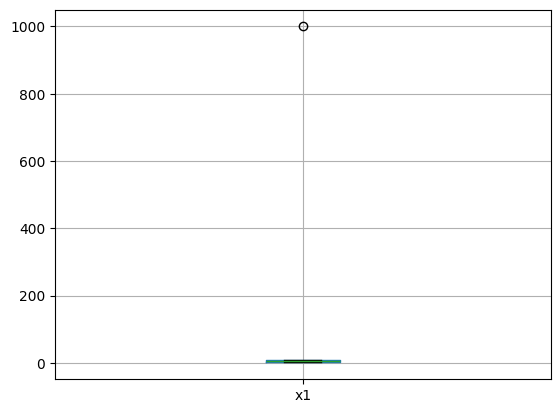

In [66]:
# 4.2. Uni-variate analysis

# 4.2.1. Numerical Variables

# 4.2.1.1. Outlier detection (visualised using box-plot)

df = pd.DataFrame({'x1': [1,2,3,4,5,6,7,8,9,1000], 'x2': [20, 30, 40, 50, 60, 70, 55, 85, 90, 25]})

print('Dataframe\n',df)

boxplot_dict = df.boxplot(column=['x1'], return_type='both')

outliers = boxplot_dict[1]['fliers'][0].get_ydata()

print('outliers for x1', outliers)

outliers for x2: []


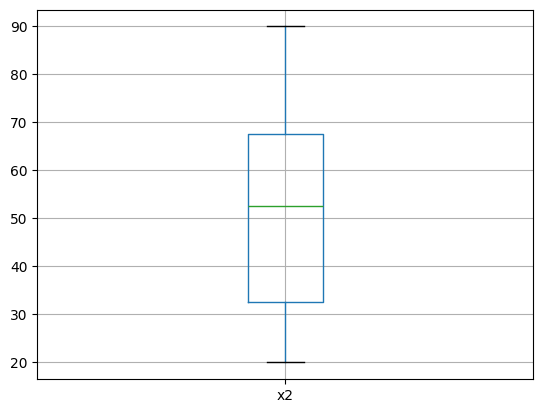

In [67]:
boxplot_dict2 = df[['x2']].boxplot(return_type = 'both')

outliers2 = boxplot_dict2[1]['fliers'][0].get_ydata()

print('outliers for x2:', outliers2)

What is to be done after detecting the outlier?

If the outlier value is greater than the third quartile, it is capped at n-1 largest value

If the outlier value is lesser than the first quartile, it is capped at next smallest value

9


<Axes: >

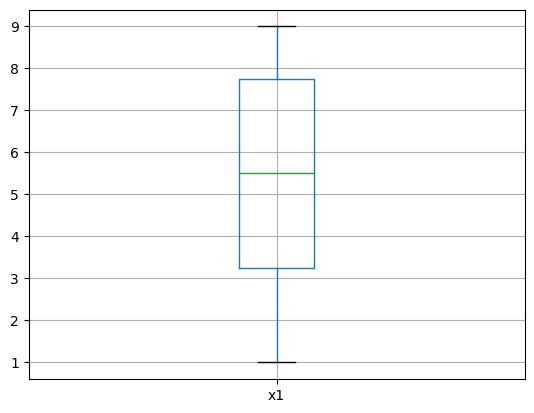

In [68]:
# clipping - pd.Series.clip(lower = lower_bound, upper = upper_bound)

# ?pd.Series.clip

next_largest = df.x1.nlargest(2).iloc[-1]
print(next_largest)
df.x1 = df.x1.clip(upper = next_largest)

df[['x1']].boxplot()

(array([301., 217., 156., 102.,  73.,  49.,  37.,  19.,  15.,  12.,   2.,
          5.,   2.,   2.,   5.,   2.,   0.,   0.,   0.,   1.]),
 array([1.83612453e-03, 7.40438710e-01, 1.47904130e+00, 2.21764388e+00,
        2.95624647e+00, 3.69484905e+00, 4.43345164e+00, 5.17205422e+00,
        5.91065681e+00, 6.64925940e+00, 7.38786198e+00, 8.12646457e+00,
        8.86506715e+00, 9.60366974e+00, 1.03422723e+01, 1.10808749e+01,
        1.18194775e+01, 1.25580801e+01, 1.32966827e+01, 1.40352853e+01,
        1.47738878e+01]),
 <BarContainer object of 20 artists>)

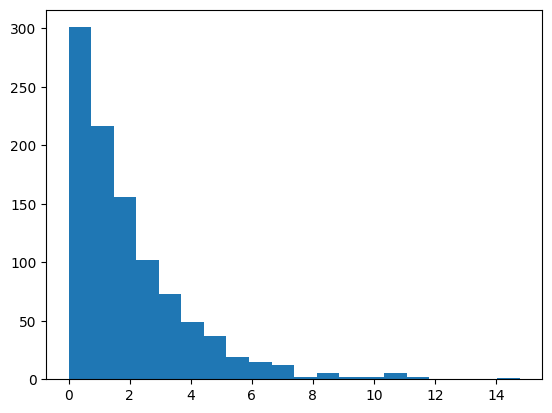

In [81]:
# 4.2.1.2. shape - normal or skewed? if skewed use log transformation or box-cox transformation

# generate dummy data
skewed_data = np.random.exponential(scale=2.0, size=1000)

plt.hist(data, bins = 20)

(array([  1.,   0.,   0.,   1.,   1.,   1.,   2.,  12.,   7.,  17.,  26.,
         29.,  59.,  91., 123., 190., 179., 173.,  71.,  17.]),
 array([-7.8063318 , -7.28510516, -6.76387853, -6.24265189, -5.72142526,
        -5.20019863, -4.67897199, -4.15774536, -3.63651872, -3.11529209,
        -2.59406546, -2.07283882, -1.55161219, -1.03038555, -0.50915892,
         0.01206771,  0.53329435,  1.05452098,  1.57574762,  2.09697425,
         2.61820088]),
 <BarContainer object of 20 artists>)

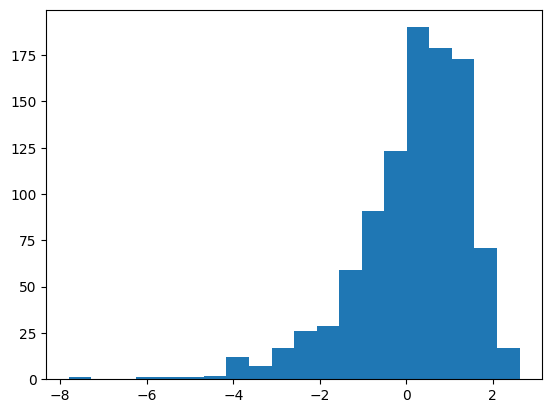

In [83]:
# data normalising by taking log-transformation

data_log = np.log(skewed_data)

plt.hist(data_log, bins = 20)

Call-out: Log-normalisation is heavily used for Income, Sales and similar variables

(array([  3.,   6.,  17.,  30.,  40.,  54.,  73.,  71., 107., 127., 104.,
         89.,  93.,  70.,  54.,  31.,  15.,   8.,   4.,   4.]),
 array([-3.02302214, -2.67336346, -2.32370479, -1.97404612, -1.62438745,
        -1.27472877, -0.9250701 , -0.57541143, -0.22575276,  0.12390591,
         0.47356459,  0.82322326,  1.17288193,  1.5225406 ,  1.87219928,
         2.22185795,  2.57151662,  2.92117529,  3.27083397,  3.62049264,
         3.97015131]),
 <BarContainer object of 20 artists>)

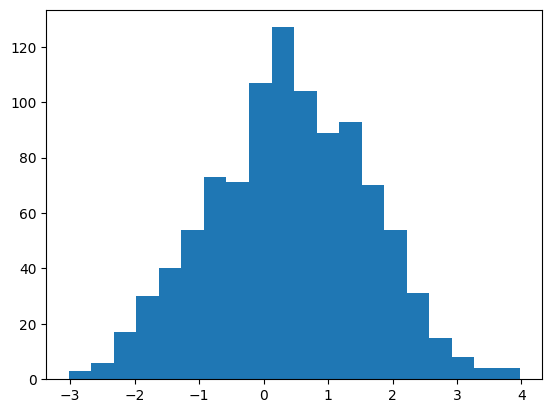

In [85]:
# data normalisation by box-cox transformation

from scipy import stats

transformed_data, best_lambda = stats.boxcox(skewed_data)

plt.hist(transformed_data, bins = 20)

Box-Cox transformation is only valid if the data has non-negative values. For negative values the Yeoh-Johnson transformation is used.

In [96]:
# 4.2.1.3. scale - standardise features by removing the mean and scaling to unit variance. z = (x-u)/s

from sklearn.preprocessing import StandardScaler

data = pd.DataFrame({'x': [1,4,5,6,2,8,5,10]})

standard_scaler = StandardScaler()

data_scaled = standard_scaler.fit_transform(data)

print('sample mean:', np.mean(data_scaled))
print('sample standard deviation:', np.std(data_scaled))

sample mean: 0.0
sample standard deviation: 1.0


In [110]:
# 4.2.2. Categorical Values - One-hot encoding

import calendar

short_months = list(calendar.month_abbr)[1:]

df = pd.DataFrame({'x': short_months})
print(df)

df_ohe = pd.get_dummies(df, drop_first = True)
df_ohe = df_ohe.astype('int')
df_ohe


      x
0   Jan
1   Feb
2   Mar
3   Apr
4   May
5   Jun
6   Jul
7   Aug
8   Sep
9   Oct
10  Nov
11  Dec


,x_Aug,x_Dec,x_Feb,x_Jan,x_Jul,x_Jun,x_Mar,x_May,x_Nov,x_Oct,x_Sep
0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0
6,0,0,0,0,1,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,1
9,0,0,0,0,0,0,0,0,0,1,0


Call-out: For only two categories it is simpler to use np.where

In [140]:
# 4.3. Multi-variate analysis

df = pd.read_csv(r'metadata\iris.csv')
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [123]:
# 4.3.1 Linear Relationship between two variables quantified the pearson's correlation coefficient

x1 = df.SepalLengthCm

x2 = df.PetalLengthCm

# using numpy
print(np.corrcoef(x1, x2)[0][1])

# using pandas
x2.corr(x1)


0.8717541573048712


np.float64(0.871754157304871)

In [143]:
# 4.3.2. Other Relationships 

# Mutual Information Criterion

from sklearn.feature_selection import mutual_info_classif  

mi = mutual_info_classif(df.iloc[:,:-1], y = df.Species)
pd.Series(mi, index = df.columns[:-1])

SepalLengthCm    0.514024
SepalWidthCm     0.225265
PetalLengthCm    0.986877
PetalWidthCm     1.003895
dtype: float64

Mutual Infomation:

Mutual information (MI) between two random variables is a non-negative
value, which measures the dependency between the variables. It is equal
to zero if and only if two random variables are independent, and higher
values mean higher dependency.

The function relies on nonparametric methods based on `entropy estimation`
from k-nearest neighbors distances.

Use sklearn.feature_selection.mutual_info_classif when dependent variable is categorical.
Use sklearn.feature_selection.mutual_info_regression when dependent variable is numerical